# Liver — LV cell-type enrichment via xCell scores

1. Load top-10 liver LVs from pre-computed SHAP results
2. Load GTEx CLAMP B matrix and xCell enrichment scores (7 cell types)
3. For each top liver LV: identify top-1% samples by B matrix value
4. Show the xCell cell-type enrichment of those top-1% samples (violin + heatmap)
5. Significant pathways (GO-BP) and GWAS traits for top liver LVs

💡 **Environment:** `clamp-analyses`

## Libraries

In [23]:
library(here)
library(CLAMP)
library(dplyr)
library(tidyr)
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(reshape2)
library(ggrepel)
library(patchwork)
library(stringr)

## Settings

In [24]:
TISSUE      <- "Liver"
TOP_N_LVS   <- 20        # number of top LVs by SHAP rank
TOP_PCT     <- 0.01      # top 1% samples per LV
FDR_PATH    <- 0.25
AUC_PATH    <- 0.60
FDR_TRAITS  <- 0.05

MODEL_PATH  <- here("output/01_model_building/02_gtex/01_CLAMP/CLAMPfull.rds")
SHAP_DIR    <- here("output/03_model_biology/01_gtex/02_rf_kmeans/00_LV_importance_kmeans/gtex_feature_importance_kmeans_binary_shap")
XCELL_PATH  <- here("data/gtex/GTEx_Analysis_v8_xCell_scores_7_celltypes.txt")
PHENO_PATH  <- here("output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz")

set.seed(42)

## Top liver LVs (SHAP)

In [25]:
cumul_df  <- read.table(file.path(SHAP_DIR, "cumulative_importance.tsv"), sep="\t", header=TRUE)
shap_df   <- read.table(file.path(SHAP_DIR, "all_shap_positive.tsv"),    sep="\t", header=TRUE)
acc_df    <- read.table(file.path(SHAP_DIR, "accuracy_summary.tsv"),     sep="\t", header=TRUE)

# accuracy for liver
print(acc_df[acc_df$Tissue == TISSUE, ])

# top-N LVs by SHAP rank
shap_liver <- shap_df[shap_df$Tissue == TISSUE, ]
shap_liver <- shap_liver[order(shap_liver$Rank), ]
top_lvs    <- shap_liver$Feature[seq_len(min(TOP_N_LVS, nrow(shap_liver)))]

# individual SHAP % per LV (diff of cumulative %)
shap_liver_top <- shap_liver[shap_liver$Feature %in% top_lvs, ]
shap_liver_top <- shap_liver_top[order(shap_liver_top$Rank), ]
indiv_pct      <- diff(c(0, shap_liver_top$Cumulative_Percent))
names(indiv_pct) <- top_lvs

# facet labels: "LV21 (8.3%)"
shap_labels <- setNames(
    paste0(top_lvs, "\n(", round(indiv_pct, 1), "% SHAP)"),
    top_lvs
)

cat("Top", TOP_N_LVS, "LVs for", TISSUE, ":\n")
print(data.frame(LV=top_lvs, indiv_pct=round(indiv_pct, 2)))

   Tissue N_Clusters Mean_Purity Best_Test_Balanced_Accuracy Mean_CV_Accuracy
10  Liver          1           1                           1        0.9955556
   Std_CV_Accuracy Imbalance_Ratio N_Positive_LVs LVs_for_80pct LVs_for_90pct
10     0.008888889        75.67699            393            31            61
Top 20 LVs for Liver :
         LV indiv_pct
LV21   LV21     11.56
LV455 LV455      8.61
LV59   LV59      7.58
LV471 LV471      7.16
LV314 LV314      3.73
LV65   LV65      3.56
LV450 LV450      3.50
LV5     LV5      3.04
LV78   LV78      2.99
LV50   LV50      2.60
LV108 LV108      2.39
LV90   LV90      2.37
LV25   LV25      2.12
LV363 LV363      1.87
LV7     LV7      1.70
LV406 LV406      1.56
LV246 LV246      1.45
LV293 LV293      1.39
LV360 LV360      1.32
LV194 LV194      1.19


## Load CLAMP B matrix and xCell scores

In [26]:
clamp_model <- readRDS(MODEL_PATH)

# B matrix: LVs x samples
B <- as.matrix(clamp_model$B)
cat("B matrix: ", nrow(B), "LVs x", ncol(B), "samples\n")

B matrix:  578 LVs x 17382 samples


In [27]:
# xCell scores: cell types x samples
xcell <- read.table(XCELL_PATH, sep="\t", header=TRUE, row.names=1, check.names=FALSE)
xcell <- as.matrix(xcell)
cat("xCell:", nrow(xcell), "cell types x", ncol(xcell), "samples\n")
cat("Cell types:", rownames(xcell), "\n")

# preview — first 6 samples
cat("\nxCell scores preview (first 6 samples):\n")
print(round(xcell[, 1:6], 4))

# align samples
common_samples <- intersect(colnames(B), colnames(xcell))
cat("\nCommon samples:", length(common_samples), "\n")

B_common     <- B[, common_samples, drop=FALSE]
xcell_common <- xcell[, common_samples, drop=FALSE]

xCell: 7 cell types x 17382 samples
Cell types: Adipocytes Epithelial_cells Hepatocytes Keratinocytes Myocytes Neurons Neutrophils 

xCell scores preview (first 6 samples):
                 GTEX-1117F-0226-SM-5GZZ7 GTEX-1117F-0426-SM-5EGHI
Adipocytes                         0.1942                   0.0412
Epithelial_cells                   0.1516                   0.0791
Hepatocytes                        0.0125                   0.0000
Keratinocytes                      0.0119                   0.0116
Myocytes                           0.0255                   0.4105
Neurons                            0.0032                   0.0055
Neutrophils                        0.0138                   0.0069
                 GTEX-1117F-0526-SM-5EGHJ GTEX-1117F-0626-SM-5N9CS
Adipocytes                         0.0000                   0.2175
Epithelial_cells                   0.0634                   0.0506
Hepatocytes                        0.0069                   0.0017
Keratinocytes          

**xCell scores** — rows are cell types, columns are GTEx samples (GTEX-XXXX-YYYY).
Values are enrichment scores (typically 0–1) estimated from bulk RNA-seq deconvolution.
Seven cell types were scored: Adipocytes, Epithelial_cells, Hepatocytes, Keratinocytes, Myocytes, Neurons, Neutrophils.
We intersect sample IDs with the CLAMP B matrix so both matrices cover the same samples.

## Top-1% samples per LV — xCell enrichment

For each top liver LV, identify the top 1% of samples (highest B value) and
compare their xCell scores against the remaining 99% (background).

In [28]:
n_top_samples <- max(1L, floor(length(common_samples) * TOP_PCT))
cat("Top", TOP_PCT*100, "% =", n_top_samples, "samples per LV\n")

# build enrichment + Wilcoxon test per LV x cell_type
enrich_list <- lapply(top_lvs, function(lv) {
    b_vals   <- B_common[lv, ]
    top_idx  <- order(b_vals, decreasing=TRUE)[seq_len(n_top_samples)]

    # mean xCell score in top-1% vs background
    top_scores <- rowMeans(xcell_common[, top_idx, drop=FALSE])
    bg_scores  <- rowMeans(xcell_common[, -top_idx, drop=FALSE])

    # Wilcoxon rank-sum test: is each cell type enriched in top-1%?
    wt_pvals <- sapply(rownames(xcell_common), function(ct) {
        wilcox.test(xcell_common[ct, top_idx],
                    xcell_common[ct, -top_idx],
                    alternative = "greater")$p.value
    })

    data.frame(
        LV          = lv,
        cell_type   = names(top_scores),
        top1pct     = as.numeric(top_scores),
        background  = as.numeric(bg_scores),
        fold_change = as.numeric(top_scores) / pmax(as.numeric(bg_scores), 1e-6),
        pvalue      = wt_pvals,
        stringsAsFactors = FALSE
    )
})
enrich_df <- do.call(rbind, enrich_list)

# BH-adjusted p-values and significance labels
enrich_df$padj <- p.adjust(enrich_df$pvalue, method = "BH")
enrich_df$sig  <- cut(enrich_df$padj,
                      breaks = c(-Inf, 0.001, 0.01, 0.05, Inf),
                      labels = c("***", "**", "*", "ns"))
enrich_df$LV <- factor(enrich_df$LV, levels = top_lvs)

cat("Enrichment + significance summary:\n")
print(enrich_df[, c("LV","cell_type","top1pct","background","fold_change","padj","sig")])

Top 1 % = 173 samples per LV
Enrichment + significance summary:
                      LV        cell_type      top1pct  background  fold_change
Adipocytes          LV21       Adipocytes 1.884572e-01 0.053736446 3.507065e+00
Epithelial_cells    LV21 Epithelial_cells 1.323457e-01 0.220529020 6.001281e-01
Hepatocytes         LV21      Hepatocytes 6.863936e-01 0.006889349 9.963114e+01
Keratinocytes       LV21    Keratinocytes 3.787283e-03 0.049834709 7.599690e-02
Myocytes            LV21         Myocytes 1.794451e-02 0.054000581 3.323021e-01
Neurons             LV21          Neurons 1.398844e-04 0.083476565 1.675733e-03
Neutrophils         LV21      Neutrophils 1.437861e-02 0.041696967 3.448359e-01
Adipocytes1        LV455       Adipocytes 1.695873e-01 0.053926143 3.144806e+00
Epithelial_cells1  LV455 Epithelial_cells 1.437705e-01 0.220414167 6.522744e-01
Hepatocytes1       LV455      Hepatocytes 6.415052e-01 0.007340607 8.739131e+01
Keratinocytes1     LV455    Keratinocytes 3.726012e-03 0

In [29]:
# ── Shared color palette and derived objects ─────────────────────────────────
ct_colors <- c(
    "Adipocytes"       = "#FC8D62",
    "Epithelial_cells" = "#8DA0CB",
    "Hepatocytes"      = "#66C2A5",
    "Keratinocytes"    = "#E78AC3",
    "Myocytes"         = "#A6D854",
    "Neurons"          = "#FFD92F",
    "Neutrophils"      = "#E5C494"
)
ct_labels <- c(
    "Adipocytes"       = "Adipocytes",
    "Epithelial_cells" = "Epithelial",
    "Hepatocytes"      = "Hepatocytes",
    "Keratinocytes"    = "Keratinocytes",
    "Myocytes"         = "Myocytes",
    "Neurons"          = "Neurons",
    "Neutrophils"      = "Neutrophils"
)

# dominant cell type per LV
dominant_df <- enrich_df %>%
    group_by(LV) %>%
    slice_max(top1pct, n = 1, with_ties = FALSE) %>%
    select(LV, dominant_ct = cell_type) %>%
    ungroup() %>%
    mutate(LV = as.character(LV))

# y-axis labels for dot plot: "LV21  (11.6%)"
lv_labels <- setNames(
    paste0(top_lvs, "  (", round(indiv_pct, 1), "%)"),
    top_lvs
)

## Cell-type enrichment across liver LVs

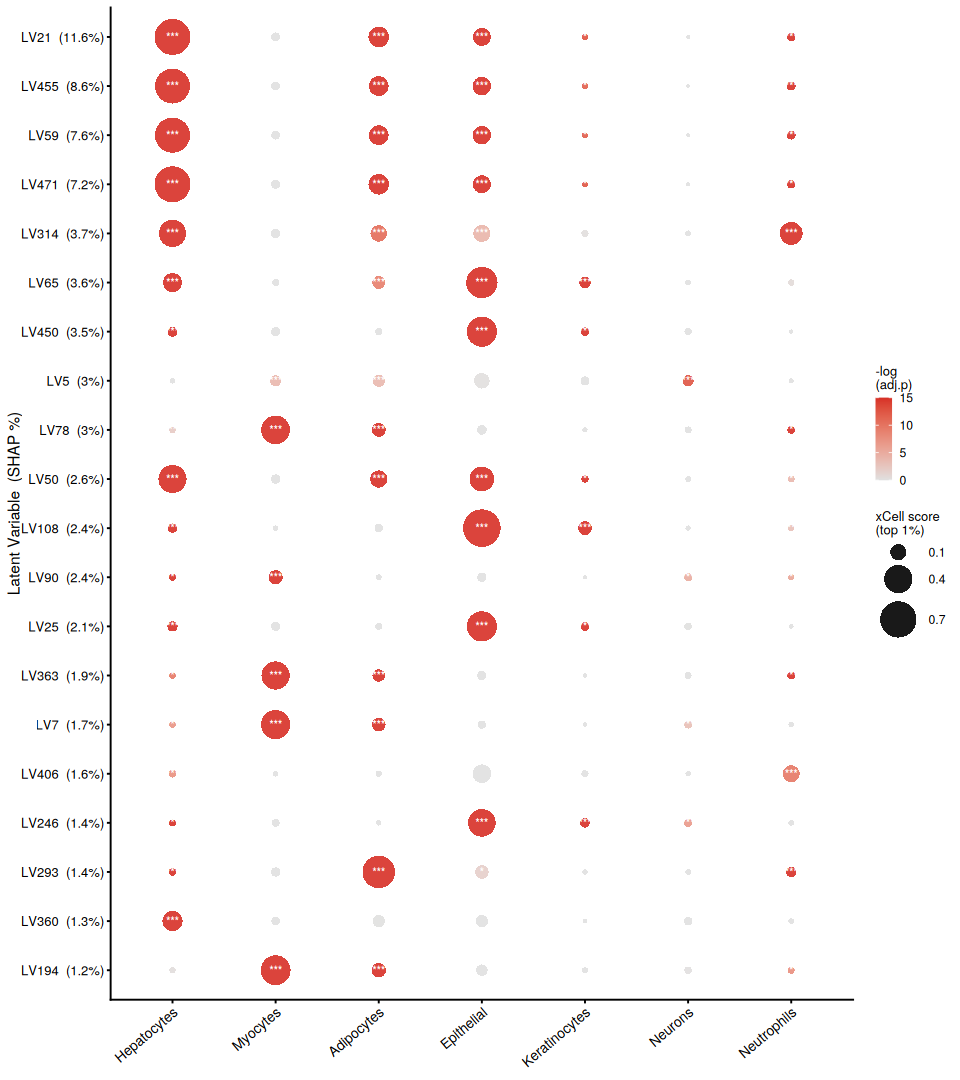

In [30]:
ct_order <- c("Hepatocytes","Myocytes","Adipocytes",
               "Epithelial_cells","Keratinocytes","Neurons","Neutrophils")
ct_xlabels <- c("Hepatocytes","Myocytes","Adipocytes",
                "Epithelial","Keratinocytes","Neurons","Neutrophils")
names(ct_xlabels) <- ct_order

dot_df <- enrich_df %>%
    mutate(
        LV        = factor(LV, levels = rev(top_lvs)),
        cell_type = factor(cell_type, levels = ct_order),
        sig_show  = ifelse(as.character(sig) != "ns", as.character(sig), NA)
    )

options(repr.plot.width = 8, repr.plot.height = 9)
ggplot(dot_df, aes(x = cell_type, y = LV)) +
    geom_point(aes(size = top1pct, color = pmin(-log10(padj + 1e-300), 15)),
               shape = 16, alpha = 0.9) +
    geom_text(aes(label = sig_show), size = 2.2, vjust = 0.4,
              color = "white", fontface = "bold", na.rm = TRUE) +
    scale_size_continuous(range = c(0.5, 10),
                          name = "xCell score\n(top 1%)",
                          breaks = c(0.1, 0.4, 0.7)) +
    scale_color_gradient(low = "grey88", high = "#d73027",
                         name = "-log\u2081\u2080\n(adj.p)") +
    scale_x_discrete(labels = ct_xlabels) +
    scale_y_discrete(labels = lv_labels) +
    labs(x = NULL, y = "Latent Variable  (SHAP %)") +
    theme_classic(base_size = 9) +
    theme(axis.text.x  = element_text(angle = 40, hjust = 1, size = 8),
          axis.text.y  = element_text(size = 7.5),
          legend.key.size  = unit(0.35, "cm"),
          legend.text  = element_text(size = 7),
          legend.title = element_text(size = 7.5))

## Hepatocyte enrichment vs SHAP importance

`geom_smooth()` using formula = 'y ~ x'


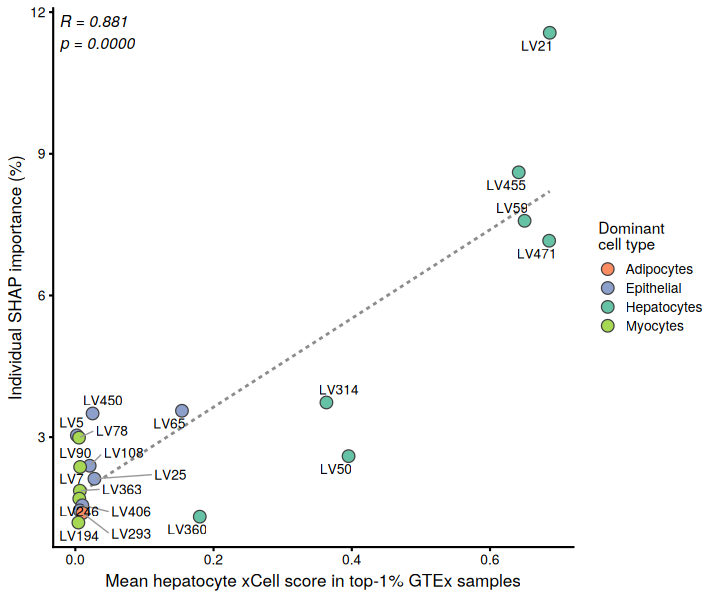

In [31]:
hepa_sc <- enrich_df %>%
    filter(cell_type == "Hepatocytes") %>%
    mutate(
        LV_chr = as.character(LV),
        shap_pct = indiv_pct[as.character(LV)]
    ) %>%
    left_join(
        dominant_df %>%
            mutate(LV = as.character(LV)) %>%
            distinct(LV, .keep_all = TRUE),
        by = c("LV_chr" = "LV")
    )

ct_cor <- cor.test(hepa_sc$top1pct, hepa_sc$shap_pct, method = "pearson")
r_val <- unname(ct_cor$estimate)

options(repr.plot.width = 6, repr.plot.height = 5)

ggplot(hepa_sc, aes(x = top1pct, y = shap_pct)) +
    geom_smooth(
        method = "lm",
        se = FALSE,
        colour = "grey55",
        linetype = "dashed",
        linewidth = 0.6
    ) +
    geom_point(
        aes(fill = dominant_ct),
        size = 3,
        shape = 21,
        colour = "grey25",
        stroke = 0.4
    ) +
    scale_fill_manual(
        values = ct_colors,
        labels = ct_labels,
        name = "Dominant\ncell type"
    ) +
    ggrepel::geom_text_repel(
        aes(label = LV_chr),
        size = 2.8,
        max.overlaps = 20,
        segment.size = 0.3,
        segment.color = "grey60"
    ) +
    annotate(
        "text",
        x = -Inf,
        y = Inf,
        hjust = -0.1,
        vjust = 1.2,
        size = 3.2,
        fontface = "italic",
        label = sprintf("R = %.3f\np = %.4f", r_val, ct_cor$p.value)
    ) +
    labs(
        x = "Mean hepatocyte xCell score in top-1% GTEx samples",
        y = "Individual SHAP importance (%)"
    ) +
    theme_classic(base_size = 10) +
    theme(
        legend.key.size = unit(0.4, "cm"),
        legend.text = element_text(size = 8),
        legend.title = element_text(size = 9)
    )

## Dominant cell type per LV (summary table)

In [32]:
dominant <- enrich_df %>%
    group_by(LV) %>%
    slice_max(top1pct, n=1) %>%
    arrange(match(LV, top_lvs)) %>%
    select(LV, dominant_cell_type=cell_type, mean_score=top1pct, fold_change)

cat("Dominant cell type per LV in top-1% samples:\n")
print(as.data.frame(dominant))

Dominant cell type per LV in top-1% samples:
      LV dominant_cell_type mean_score fold_change
1   LV21        Hepatocytes 0.68639364   99.631138
2  LV455        Hepatocytes 0.64150520   87.391306
3   LV59        Hepatocytes 0.64999364   89.589131
4  LV471        Hepatocytes 0.68552139   99.378042
5  LV314        Hepatocytes 0.36329711   35.837310
6   LV65   Epithelial_cells 0.50179884    2.314411
7  LV450   Epithelial_cells 0.46159191    2.125006
8    LV5   Epithelial_cells 0.09175318    0.415291
9   LV78           Myocytes 0.41344913    8.264913
10  LV50        Hepatocytes 0.39534220   40.278347
11 LV108   Epithelial_cells 0.75370925    3.517362
12  LV90           Myocytes 0.07239595    1.354380
13  LV25   Epithelial_cells 0.46412428    2.136914
14 LV363           Myocytes 0.40019075    7.978618
15   LV7           Myocytes 0.42821561    8.585574
16 LV406   Epithelial_cells 0.14761676    0.669842
17 LV246   Epithelial_cells 0.37804566    1.733685
18 LV293         Adipocytes 0.5444809

## Pathways (GO-BP from CLAMP summary)

In [33]:
summary_df <- clamp_model$summary
summary_df$pathway <- gsub("C2CP_", "", summary_df$pathway)

# top-3 cell types per LV (by mean xCell score in top-1%)
top3_cells <- enrich_df %>%
    group_by(LV) %>%
    slice_max(top1pct, n=5, with_ties=FALSE) %>%
    summarise(top_cells = paste(cell_type, collapse=", "), .groups="drop") %>%
    mutate(LV = as.character(LV))

pathways_liver <- summary_df[
    summary_df$LV  %in% top_lvs &
    summary_df$FDR <= FDR_PATH &
    summary_df$AUC >= AUC_PATH, c("LV","pathway")]
pathways_liver <- pathways_liver[order(
    match(pathways_liver$LV, top_lvs), pathways_liver$pathway), ]
pathways_liver <- merge(pathways_liver, top3_cells, by="LV", all.x=TRUE)
pathways_liver <- pathways_liver[order(match(pathways_liver$LV, top_lvs)), ]
rownames(pathways_liver) <- NULL

cat("Significant pathways (FDR <=", FDR_PATH, ", AUC >=", AUC_PATH, "):",
    nrow(pathways_liver), "\n")
pathways_liver

Significant pathways (FDR <= 0.25 , AUC >= 0.6 ): 43 


LV,pathway,top_cells
<chr>,<chr>,<chr>
LV21,BP_Modified Amino Acid Catabolic Process (GO:0042219),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV455,BP_Low-Density Lipoprotein Particle Remodeling (GO:0034374),"Hepatocytes, Adipocytes, Epithelial_cells, Neutrophils, Myocytes"
LV455,BP_Negative Regulation of Extrinsic Apoptotic Signaling Pathway via Death Domain Receptors (GO:1902042),"Hepatocytes, Adipocytes, Epithelial_cells, Neutrophils, Myocytes"
LV59,BP_Carbohydrate Derivative Catabolic Process (GO:1901136),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV59,BP_Negative Regulation of Coagulation (GO:0050819),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV59,BP_Negative Regulation of Complement Activation (GO:0045916),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV471,BP_Estrogen Metabolic Process (GO:0008210),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV471,BP_Fatty Acid Beta-Oxidation Using acyl-CoA Oxidase (GO:0033540),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV471,BP_Regulation of Glycogen Metabolic Process (GO:0070873),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"


## GWAS traits (PhenoPLIER)

In [34]:
phenoplier <- read.table(PHENO_PATH, sep="\t", header=TRUE, comment.char="")

# top-3 cell types per LV (reuse from above)
traits_liver <- phenoplier[
    phenoplier$lv  %in% top_lvs &
    phenoplier$fdr <= FDR_TRAITS,
    c("lv","phenotype_desc")]
colnames(traits_liver)[1] <- "LV"
traits_liver <- traits_liver[order(match(traits_liver$LV, top_lvs)), ]
traits_liver <- merge(traits_liver, top3_cells, by="LV", all.x=TRUE)
traits_liver <- traits_liver[order(match(traits_liver$LV, top_lvs)), ]
rownames(traits_liver) <- NULL

cat("Significant trait associations (FDR <=", FDR_TRAITS, "):",
    nrow(traits_liver), "\n")
traits_liver

Significant trait associations (FDR <= 0.05 ): 58 


LV,phenotype_desc,top_cells
<chr>,<chr>,<chr>
LV21,Coffee intake,"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV21,"Non-cancer illness code, self-reported: high cholesterol","Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV21,Treatment/medication code: simvastatin (20003_1140861958),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV21,Treatment/medication code: atorvastatin (20003_1141146234),"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV21,Diagnoses - main ICD10: D10 Benign neoplasm of mouth and pharynx,"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV21,Diagnoses - main ICD10: K80 Cholelithiasis,"Hepatocytes, Adipocytes, Epithelial_cells, Myocytes, Neutrophils"
LV455,"Non-cancer illness code, self-reported: cholelithiasis/gall stones","Hepatocytes, Adipocytes, Epithelial_cells, Neutrophils, Myocytes"
LV455,"Non-cancer illness code, self-reported: high cholesterol","Hepatocytes, Adipocytes, Epithelial_cells, Neutrophils, Myocytes"
LV455,Treatment/medication code: simvastatin (20003_1140861958),"Hepatocytes, Adipocytes, Epithelial_cells, Neutrophils, Myocytes"


## Panel C — Pathways and traits for selected LVs

LV21 (Hepatocytes, top SHAP), LV455 (Hepatocytes), LV5 (Epithelial + Neuronal — highest neuronal proportion), LV293 (Adipocytes)


In [35]:
SELECTED_LVS <- c("LV21", "LV455", "LV5", "LV293")

clean_pw <- function(x) {
    x <- gsub("^(BP_|C2CP_)", "", x)
    x <- gsub(" \\(GO:[0-9]+\\)", "", x)
    x <- gsub("_", " ", x)
    stringr::str_trunc(x, 52)
}
clean_tr <- function(x) {
    x <- sub("Treatment/medication code: ", "", x)
    x <- sub("Non-cancer illness code, self-reported: ", "", x)
    x <- sub("Diagnoses - main ICD10: [A-Z][0-9]+\\.?[0-9]* ?", "", x)
    x <- sub("Medication for cholesterol.*?: ", "", x)
    x <- sub("Blood clot.*?: ", "Allergy: ", x)
    x <- sub("Illnesses of mother: ", "Maternal: ", x)
    x <- sub(" \\(20003_[0-9]+\\)", "", x)
    stringr::str_to_sentence(stringr::str_trunc(x, 52))
}

# top-2 cell types per LV (by mean xCell score in top-1%)
top2_cells <- enrich_df %>%
    group_by(LV) %>%
    slice_max(top1pct, n = 2, with_ties = FALSE) %>%
    summarise(top2_labels = paste(ct_labels[cell_type], collapse = ", "), .groups = "drop") %>%
    mutate(LV = as.character(LV))

# pathways: top-5 by AUC per LV
pathways_sel <- clamp_model$summary %>%
    filter(LV %in% SELECTED_LVS, AUC >= 0.45) %>%
    mutate(pathway_clean = clean_pw(pathway),
           neg_log_fdr   = pmin(-log10(FDR + 1e-300), 3),
           bubble_size   = 2 + ((AUC - 0.45) / 0.55) * 8) %>%
    group_by(LV) %>%
    slice_max(AUC, n = 5, with_ties = FALSE) %>%
    ungroup() %>%
    left_join(top2_cells, by = "LV") %>%
    mutate(LV = factor(LV, levels = SELECTED_LVS))

# traits: top-8 by FDR per LV (FDR < 0.01)
traits_sel <- phenoplier %>%
    filter(lv %in% SELECTED_LVS, fdr <= 0.01) %>%
    rename(LV = lv) %>%
    mutate(trait_clean  = clean_tr(phenotype_desc),
           neg_log_fdr  = -log10(fdr + 1e-300)) %>%
    group_by(LV) %>%
    slice_min(fdr, n = 8, with_ties = FALSE) %>%
    ungroup() %>%
    left_join(top2_cells, by = "LV") %>%
    mutate(LV = factor(LV, levels = SELECTED_LVS))

cat("Pathways per LV:\n"); print(table(pathways_sel$LV))
cat("Traits per LV:\n");   print(table(traits_sel$LV))

Pathways per LV:

 LV21 LV455   LV5 LV293 
    5     5     5     5 
Traits per LV:

 LV21 LV455   LV5 LV293 
    2     8     0     0 


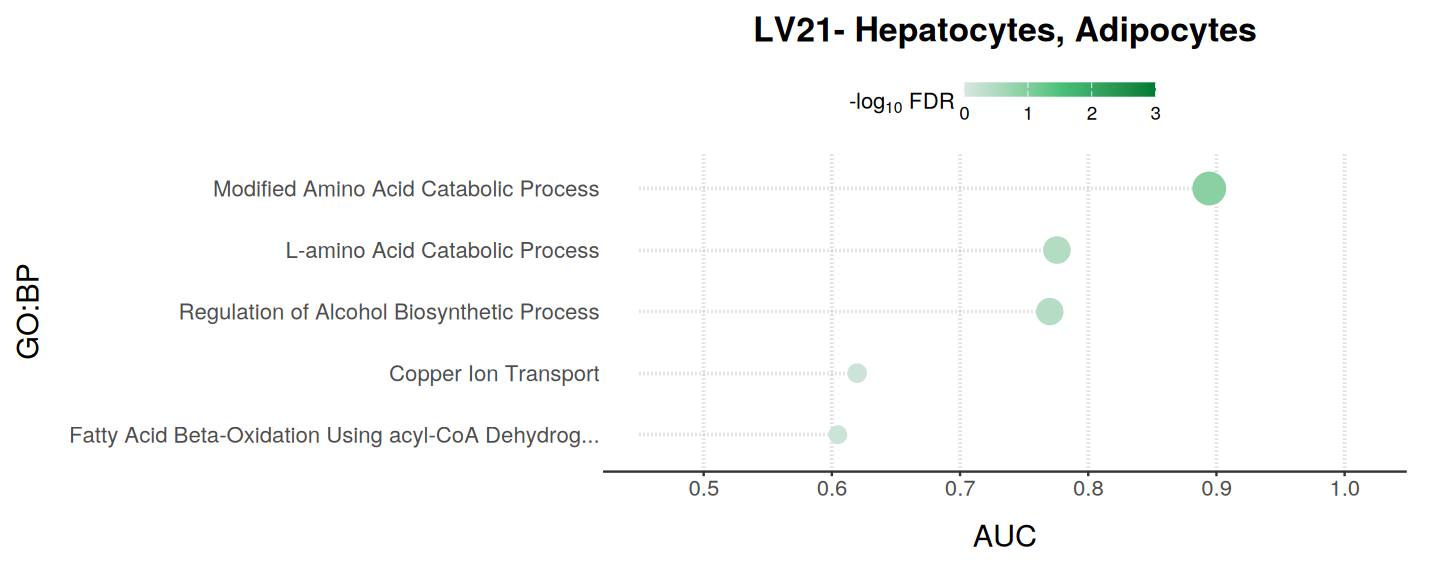

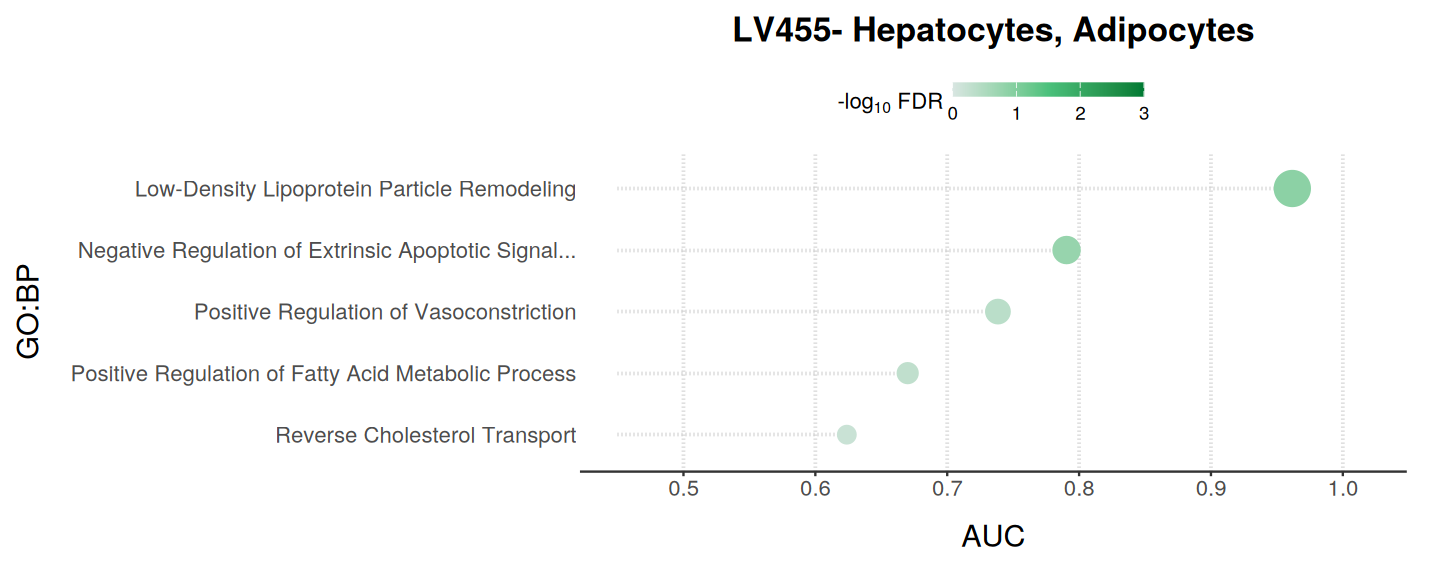

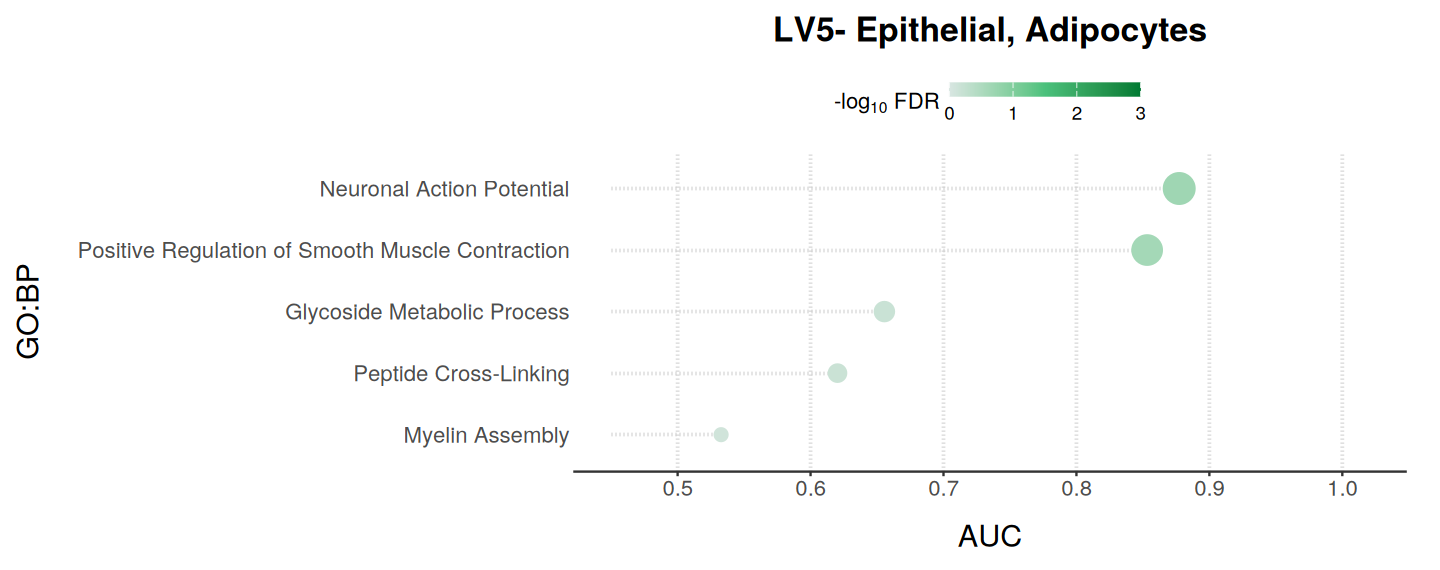

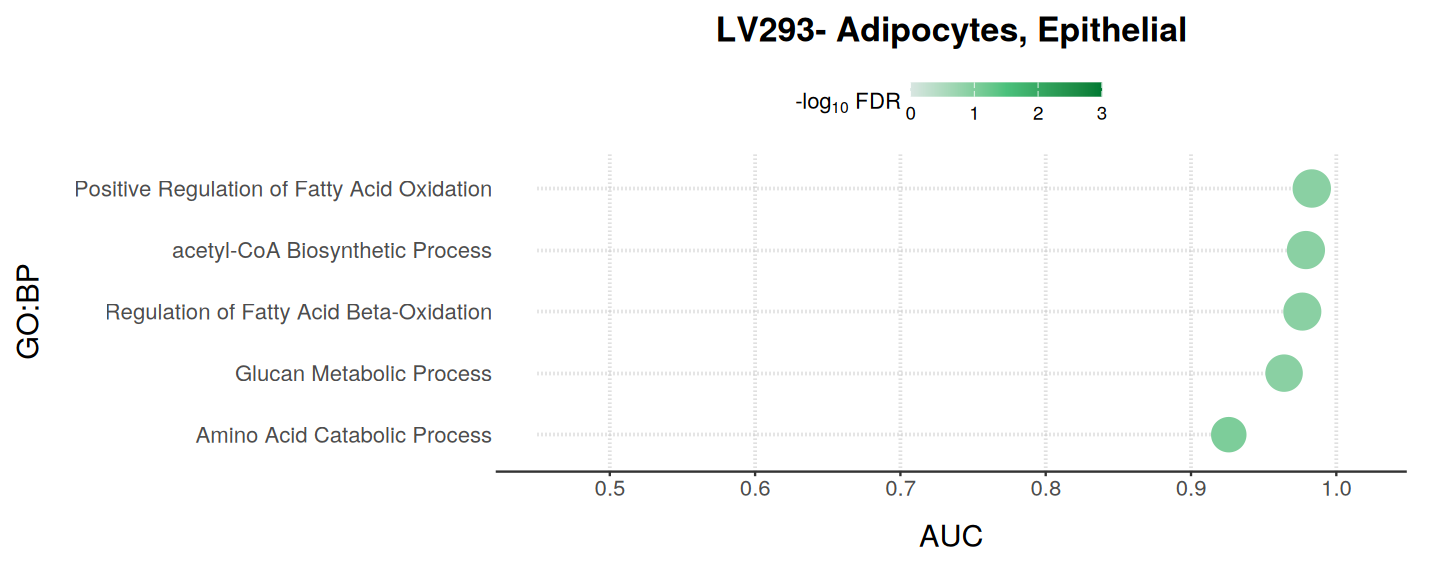

In [36]:
bubble_theme <- theme(
    panel.background    = element_rect(fill = "white", color = NA),
    plot.background     = element_rect(fill = "white", color = NA),
    panel.grid.major.x  = element_line(linetype = "dotted", linewidth = 0.8, color = "#cccccc"),
    panel.grid.major.y  = element_blank(),
    panel.grid.minor    = element_blank(),
    axis.line.x         = element_line(color = "#333333", linewidth = 0.5),
    axis.line.y         = element_blank(),
    axis.ticks.y        = element_blank(),
    axis.text.y         = element_text(size = 13, hjust = 1),
    axis.text.x         = element_text(size = 13),
    axis.title.x        = element_text(size = 18, margin = margin(t = 15)),
    axis.title.y        = element_text(size = 18, angle = 90, margin = margin(r = 10)),
    plot.title          = element_text(size = 20, hjust = 0.5, face = "bold",
                                       margin = margin(b = 14)),
    plot.title.position = "panel",
    legend.position     = "top",
    legend.title        = element_text(size = 13),
    legend.text         = element_text(size = 11),
    plot.margin         = margin(10, 20, 10, 10)
)

green_colors <- c("#d9e6e2", "#4bc17c", "#007a33")

for (lv in SELECTED_LVS) {
    d <- pathways_sel %>%
        filter(LV == lv) %>%
        arrange(AUC) %>%
        mutate(label = factor(pathway_clean, levels = unique(pathway_clean)))

    if (nrow(d) == 0) {
        cat(lv, "— no significant pathways\n"); next
    }

    top2_lbl <- d$top2_labels[1]
    n_items  <- nrow(d)
    fdr_max  <- max(3, ceiling(max(d$neg_log_fdr, na.rm = TRUE)))

    fig_h <- 2.0 + 0.55 * n_items
    options(repr.plot.width = 12, repr.plot.height = fig_h)

    p <- ggplot(d, aes(x = AUC, y = label)) +
        geom_segment(aes(x = 0.45, xend = AUC, yend = label),
                     color = "#cccccc", linewidth = 0.8, linetype = "dotted") +
        geom_point(aes(color = neg_log_fdr, size = bubble_size)) +
        scale_color_gradientn(
            colors = green_colors,
            limits = c(0, fdr_max),
            name   = expression("-" * log[10] ~ FDR)
        ) +
        scale_size_identity(guide = "none") +
        scale_x_continuous(limits = c(0.45, 1.02),
                           breaks = seq(0.5, 1.0, by = 0.1)) +
        labs(x     = "AUC",
             y     = "GO:BP",
             title = paste0(lv, "- ", top2_lbl)) +
        bubble_theme +
        guides(color = guide_colorbar(barwidth = 8, barheight = 0.6,
                                      title.position = "left",
                                      title.hjust = 1))

    print(p)
}

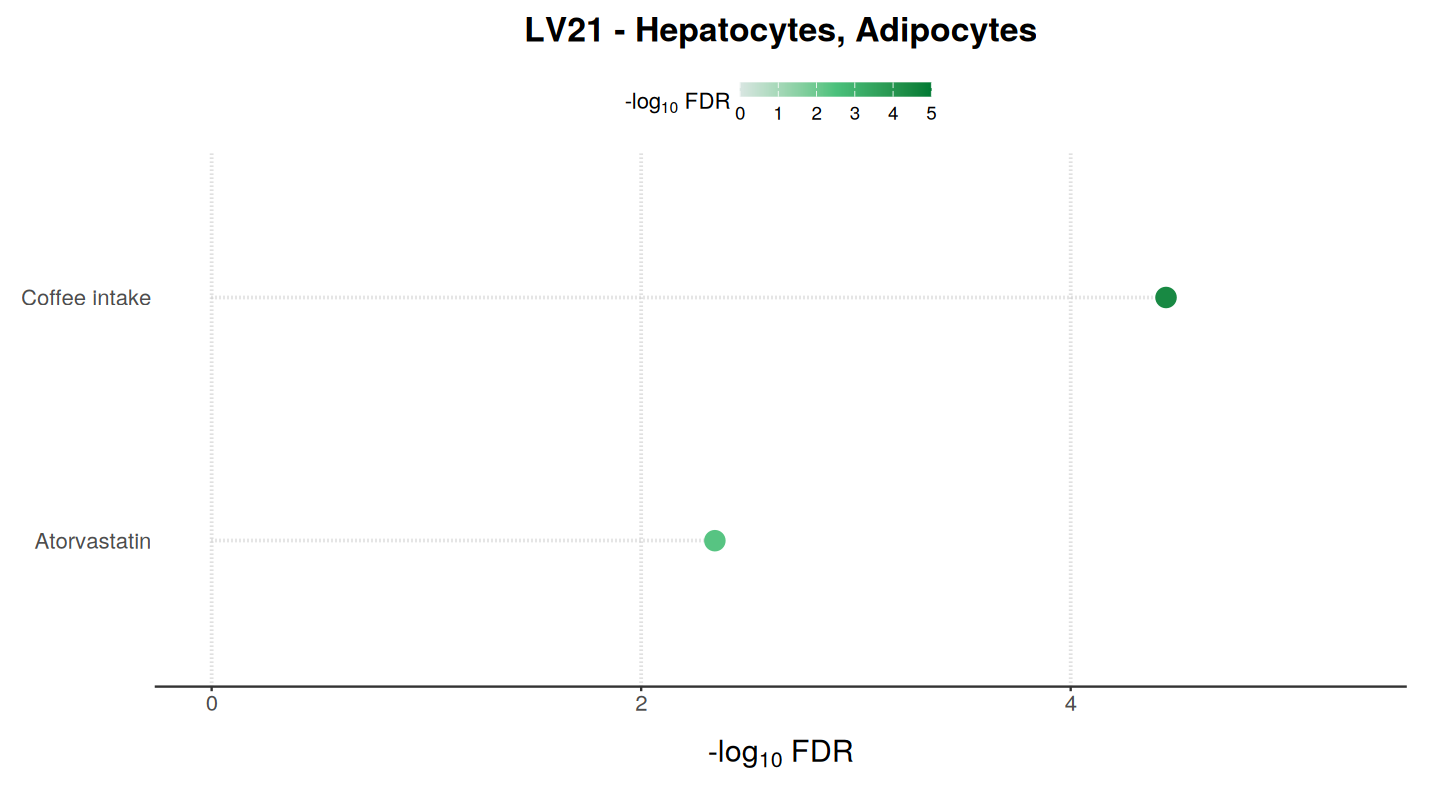

LV5 — no significant traits (FDR < 0.01)
LV293 — no significant traits (FDR < 0.01)


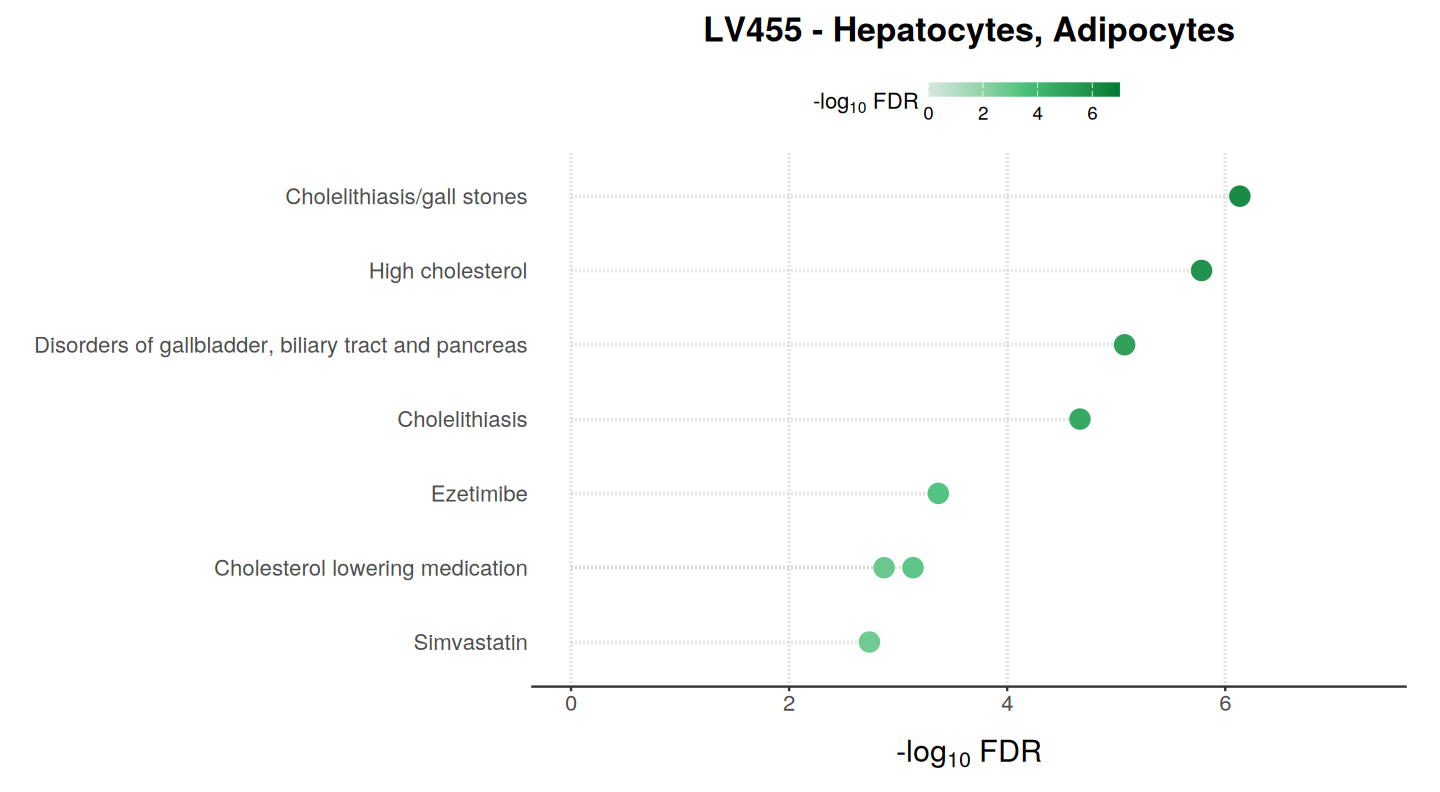

In [37]:
for (lv in SELECTED_LVS) {
    d <- traits_sel %>%
        filter(LV == lv) %>%
        arrange(neg_log_fdr) %>%
        mutate(label = factor(trait_clean, levels = unique(trait_clean)))

    if (nrow(d) == 0) {
        cat(lv, "— no significant traits (FDR < 0.01)\n"); next
    }

    top2_lbl <- d$top2_labels[1]
    n_items  <- nrow(d)
    v_max    <- max(3.0, ceiling(max(d$neg_log_fdr, na.rm = TRUE)))

    fig_h <- 2.2 + 0.55 * n_items
    options(repr.plot.width = 12, repr.plot.height = fig_h)

    p <- ggplot(d, aes(x = neg_log_fdr, y = label)) +
        geom_segment(aes(x = 0, xend = neg_log_fdr, yend = label),
                     color = "#cccccc", linewidth = 0.8, linetype = "dotted") +
        geom_point(aes(color = neg_log_fdr), size = 5) +
        scale_color_gradientn(
            colors = green_colors,
            limits = c(0, v_max),
            name   = expression("-" * log[10] ~ FDR)
        ) +
        scale_x_continuous(limits = c(0, v_max + 0.3)) +
        labs(x     = expression("-" * log[10] ~ FDR),
             y     = NULL,
             title = paste0(lv, " - ", top2_lbl)) +
        bubble_theme +
        guides(color = guide_colorbar(barwidth = 8, barheight = 0.6,
                                      title.position = "left",
                                      title.hjust = 1))

    print(p)
}

## Save panel data

Saves xCell scatter and selected LV pathway/trait data for fig3 panel.

In [38]:
# ── Save liver xCell and selected LV data for fig3 panel ─────────────────────
dir.create(here('output/99_panels/fig3'), showWarnings = FALSE, recursive = TRUE)

# xCell hepatocyte scatter data
write.csv(hepa_sc, here('output/99_panels/fig3/liver_xcell_scatter.csv'), row.names = FALSE)
cat('Saved liver_xcell_scatter.csv
')

# Selected LV pathway and trait data
# Rename FDR -> fdr so fig3 panel code can reference it consistently (lowercase)
pathways_out <- as.data.frame(pathways_sel) %>% rename(fdr = FDR)
write.csv(pathways_out, here('output/99_panels/fig3/liver_lv_pathways.csv'), row.names = FALSE)
write.csv(as.data.frame(traits_sel), here('output/99_panels/fig3/liver_lv_traits.csv'), row.names = FALSE)
cat('Saved liver_lv_pathways.csv and liver_lv_traits.csv
')

# Cell-type enrichment percentage per LV (for LV title annotations in fig3 panel)
# Normalises top-1% xCell scores within each LV so they sum to 100 %
celltypes_df <- enrich_df %>%
    select(LV, cell_type, top1pct) %>%
    group_by(LV) %>%
    mutate(percentage = top1pct / sum(top1pct) * 100) %>%
    ungroup() %>%
    mutate(LV = as.character(LV))
write.csv(celltypes_df, here('output/99_panels/fig3/liver_lv_celltypes.csv'), row.names = FALSE)
cat('Saved liver_lv_celltypes.csv
')

# Also save ct_colors and indiv_pct for reproducibility in panel notebook
ct_meta <- data.frame(
    cell_type = names(ct_colors),
    color     = unname(ct_colors),
    label     = unname(ct_labels[names(ct_colors)]),
    stringsAsFactors = FALSE
)
write.csv(ct_meta, here('output/99_panels/fig3/liver_ct_meta.csv'), row.names = FALSE)

shap_meta <- data.frame(
    LV       = names(indiv_pct),
    shap_pct = unname(indiv_pct),
    stringsAsFactors = FALSE
)
write.csv(shap_meta, here('output/99_panels/fig3/liver_lv_shap_pct.csv'), row.names = FALSE)
cat('Saved ct_meta and lv_shap_pct
')

Saved liver_xcell_scatter.csv
Saved liver_lv_pathways.csv and liver_lv_traits.csv
Saved liver_lv_celltypes.csv
Saved ct_meta and lv_shap_pct
